<a href="https://colab.research.google.com/github/aalitorres/PIA-PDI/blob/main/Proyecto_Final_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final**

###**Mejora y Segmentación de Imágenes Médicas para Diagnóstico Asistido por Computadora**

**Materia:** Procesamiento Digital de Imágenes

**Carrera:** Ingeniería Biomédica

**Universidad:** Universidad Autónoma de Nuevo León

**Equipo:** 2

**Objetivo**

Desarrollar un algoritmo en Python para el procesamiento de imágenes médicas en formato DICOM mediante técnicas clásicas de procesamiento digital de imágenes. El proyecto incluye el análisis y ecualización de histogramas, operaciones aritméticas y lógicas, aplicación de filtros espaciales, segmentación por umbral y procesamiento en el dominio de la frecuencia mediante la Transformada de Fourier, con el fin de resaltar estructuras anatómicas de interés para el diagnóstico asistido por computadora.


In [2]:
!pip install -q pydicom

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pydicom

plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["image.cmap"] = "gray"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 67.3 MB/s eta 0:00:00


**1. Lectura de la imagen médica**

Las imágenes utilizadas en este proyecto se encuentran en formato DICOM (Digital Imaging and Communications in Medicine), el cual es el estándar internacional para el almacenamiento e intercambio de imágenes médicas.

A diferencia de formatos convencionales como JPG o PNG, un archivo DICOM almacena tanto la imagen como información adicional del estudio médico, por ejemplo, el tamaño de la imagen, el tipo de estudio y diversos parámetros de adquisición.

Para acceder a la imagen se utiliza la biblioteca pydicom, la cual permite obtener la matriz de píxeles que posteriormente será procesada mediante OpenCV.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving 1-001.dcm to 1-001.dcm


Dimensiones: (512, 512)
Tipo de dato: int16


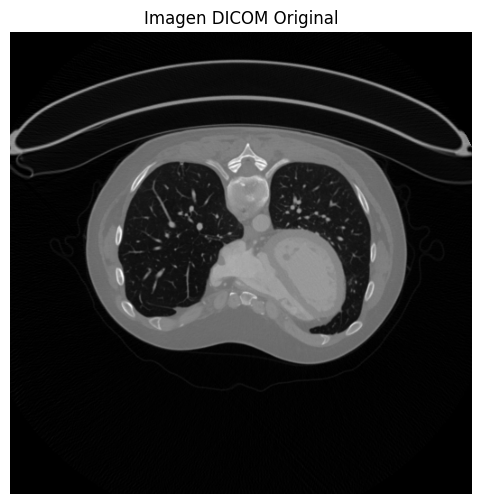

In [4]:
dcm = pydicom.dcmread("1-001.dcm")

imagen_dicom = dcm.pixel_array

print("Dimensiones:", imagen_dicom.shape)
print("Tipo de dato:", imagen_dicom.dtype)

# Mostrar la imagen
plt.figure(figsize=(6,6))
plt.imshow(imagen_dicom, cmap="gray")
plt.title("Imagen DICOM Original")
plt.axis("off")
plt.show()

**2. Normalización de la imagen**

Las imágenes DICOM se almacenan normalmente con una profundidad de 16 bits, lo que permite representar un mayor rango de intensidades. Sin embargo, OpenCV trabaja principalmente con imágenes de 8 bits, por lo que es necesario normalizar la imagen al rango de 0 a 255 antes de aplicar las técnicas de procesamiento, conservando la relación de intensidades entre los píxeles.

Nuevo tipo de dato: uint8


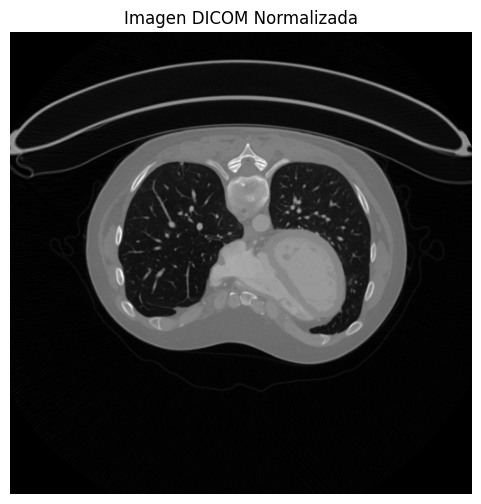

In [5]:
imagen_normalizada = cv2.normalize(
    imagen_dicom,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

imagen_normalizada = imagen_normalizada.astype(np.uint8)

print("Nuevo tipo de dato:", imagen_normalizada.dtype)

plt.figure(figsize=(6,6))
plt.imshow(imagen_normalizada, cmap="gray")
plt.title("Imagen DICOM Normalizada")
plt.axis("off")
plt.show()

**3. Análisis del histograma**

El histograma representa la distribución de intensidades de los píxeles presentes en una imagen. Su análisis permite conocer la cantidad de píxeles oscuros, medios y brillantes, proporcionando información acerca del contraste y la iluminación de la imagen.

En esta sección se calculará el histograma de la imagen médica utilizando la función `cv2.calcHist()`.

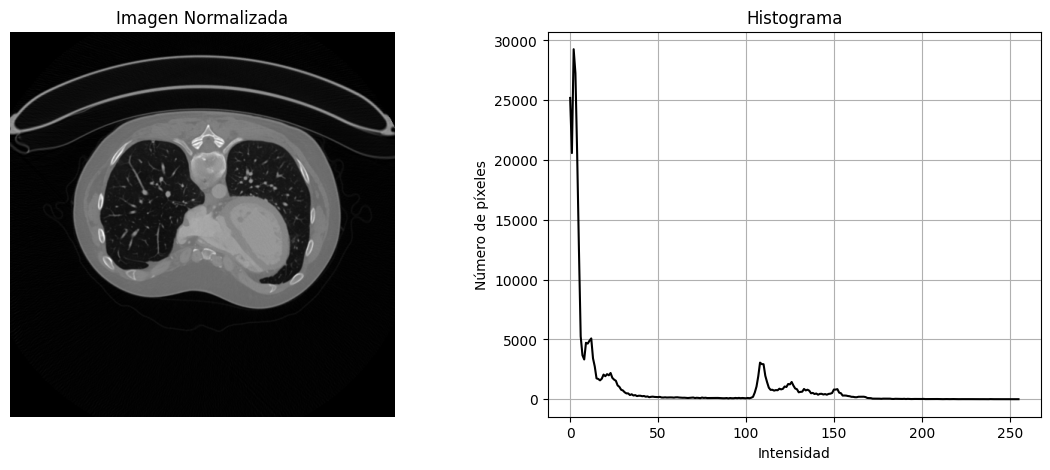

In [6]:
# Calcular el histograma
hist = cv2.calcHist([imagen_normalizada], [0], None, [256], [0,256])

# Mostrar imagen e histograma
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada, cmap='gray')
plt.title("Imagen Normalizada")
plt.axis("off")

plt.subplot(1,2,2)
plt.plot(hist, color='black')
plt.title("Histograma")
plt.xlabel("Intensidad")
plt.ylabel("Número de píxeles")
plt.grid()

plt.show()

El histograma muestra la distribución de las intensidades de la imagen. Se observa una mayor concentración de píxeles en intensidades bajas, correspondientes al fondo, y picos en intensidades medias que representan las estructuras anatómicas.

**4. Ecualización del histograma**

La ecualización del histograma mejora el contraste de la imagen al redistribuir las intensidades de los píxeles, lo que facilita la visualización de estructuras anatómicas con diferencias de intensidad poco visibles.

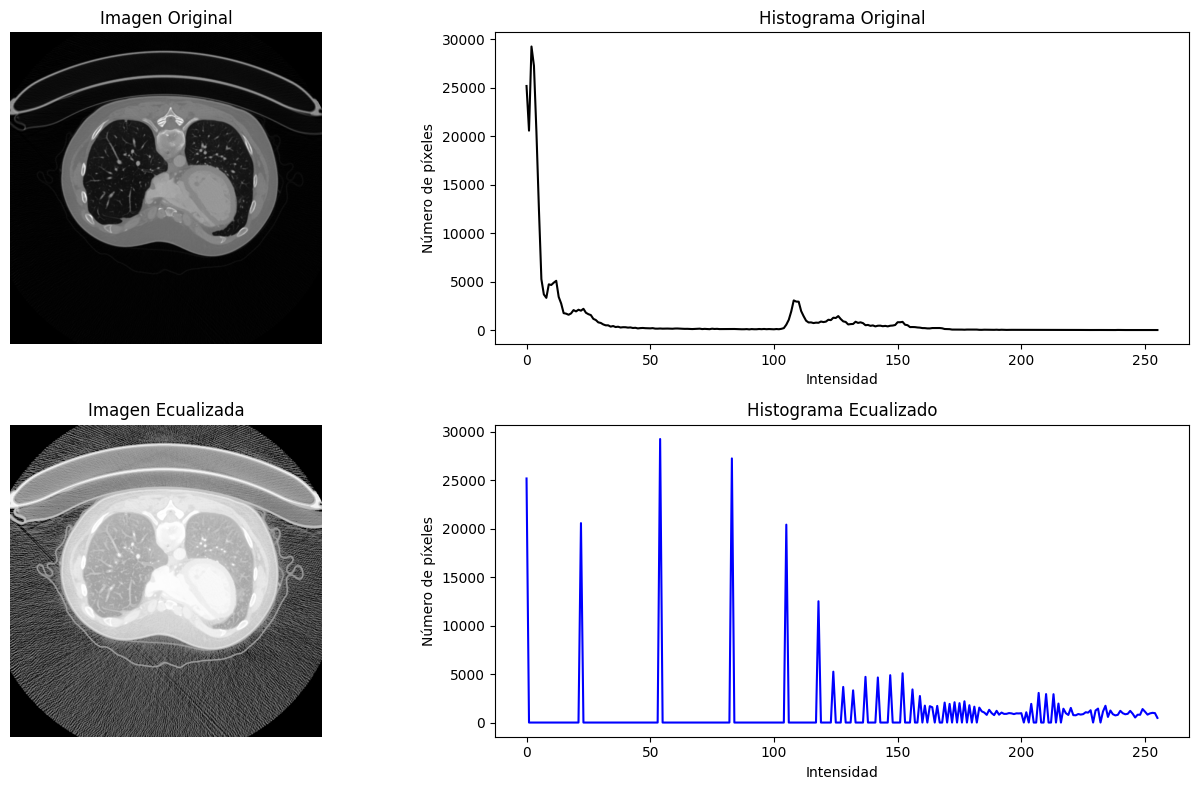

In [7]:
imagen_ecualizada = cv2.equalizeHist(imagen_normalizada)

# Calcular histogramas
hist_original = cv2.calcHist([imagen_normalizada], [0], None, [256], [0,256])
hist_ecualizado = cv2.calcHist([imagen_ecualizada], [0], None, [256], [0,256])

# Mostrar resultados
plt.figure(figsize=(14,8))

plt.subplot(2,2,1)
plt.imshow(imagen_normalizada, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.plot(hist_original, color="black")
plt.title("Histograma Original")
plt.xlabel("Intensidad")
plt.ylabel("Número de píxeles")

plt.subplot(2,2,3)
plt.imshow(imagen_ecualizada, cmap="gray")
plt.title("Imagen Ecualizada")
plt.axis("off")

plt.subplot(2,2,4)
plt.plot(hist_ecualizado, color="blue")
plt.title("Histograma Ecualizado")
plt.xlabel("Intensidad")
plt.ylabel("Número de píxeles")

plt.tight_layout()
plt.show()

Después de la ecualización se observa una mejor distribución de las intensidades, incrementando el contraste y permitiendo distinguir con mayor claridad algunas estructuras presentes en la imagen.

**5. Filtrado espacial**

Los filtros espaciales permiten reducir el ruido presente en la imagen antes de aplicar otras técnicas de procesamiento. En esta sección se utilizará un filtro Gaussiano para suavizar la imagen y posteriormente comparar el resultado con la imagen original.

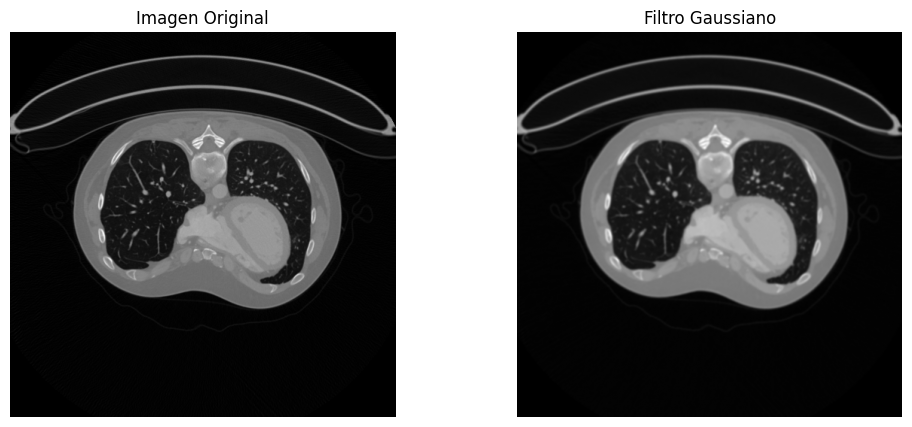

In [8]:
imagen_gaussiana = cv2.GaussianBlur(
    imagen_normalizada,
    (5,5),
    0
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada, cmap='gray')
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_gaussiana, cmap='gray')
plt.title("Filtro Gaussiano")
plt.axis("off")

plt.show()

El filtro Gaussiano reduce pequeñas variaciones de intensidad presentes en la imagen, disminuyendo el ruido y generando una imagen más suave para etapas posteriores del procesamiento.

Filtro de Media

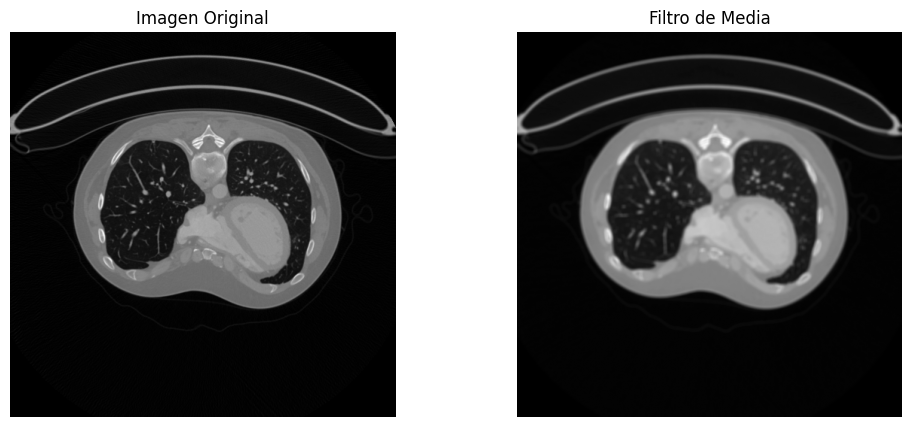

In [9]:
imagen_media = cv2.blur(
    imagen_normalizada,
    (5,5)
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_media, cmap="gray")
plt.title("Filtro de Media")
plt.axis("off")

plt.show()

**6. Operación aritmética**

Para resaltar los bordes presentes en la imagen se realiza la resta entre la imagen original y la imagen suavizada mediante un filtro Gaussiano.

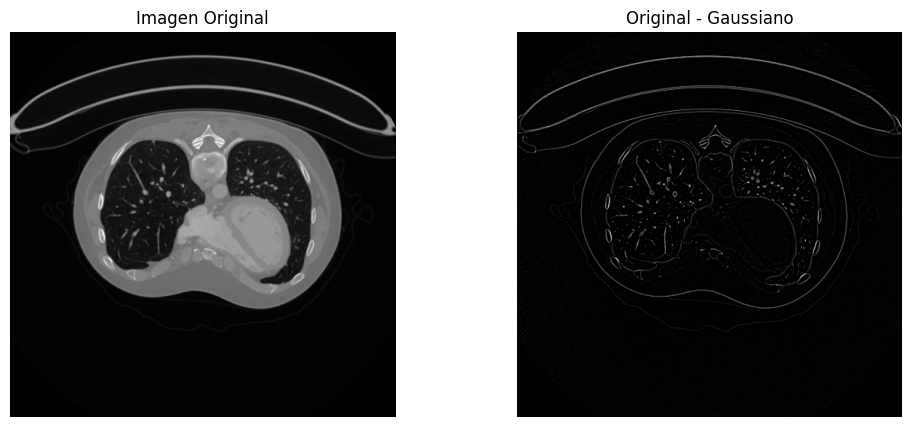

In [ ]:
imagen_bordes = cv2.subtract(
    imagen_normalizada,
    imagen_gaussiana
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada, cmap='gray')
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_bordes, cmap='gray')
plt.title("Original - Gaussiano")
plt.axis("off")

plt.show()

La resta entre la imagen original y la imagen suavizada permite resaltar las zonas donde existen cambios bruscos de intensidad, haciendo más visibles los bordes de las estructuras anatómicas.

**Funciones del Proyecto**

In [ ]:
def normalizar_imagen(imagen):
    """
    Convierte una imagen DICOM al rango de 0 a 255.
    """
    imagen = cv2.normalize(
        imagen,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return imagen.astype(np.uint8)


def calcular_histograma(imagen):
    """
    Calcula el histograma de una imagen.
    """
    return cv2.calcHist([imagen], [0], None, [256], [0,256])


def ecualizar_histograma(imagen):
    """
    Aplica ecualización del histograma.
    """
    return cv2.equalizeHist(imagen)


def filtro_gaussiano(imagen, kernel=(5,5)):
    """
    Aplica un filtro Gaussiano.
    """
    return cv2.GaussianBlur(imagen, kernel, 0)


def resaltar_bordes(imagen_original, imagen_suavizada):
    """
    Resta la imagen suavizada a la original.
    """
    return cv2.subtract(imagen_original, imagen_suavizada)

**7. Segmentación por umbral**

La segmentación por umbral consiste en separar las regiones de interés de la imagen a partir de un valor de intensidad. En esta sección se aplicará una umbralización binaria para generar una máscara que posteriormente será utilizada en operaciones lógicas.

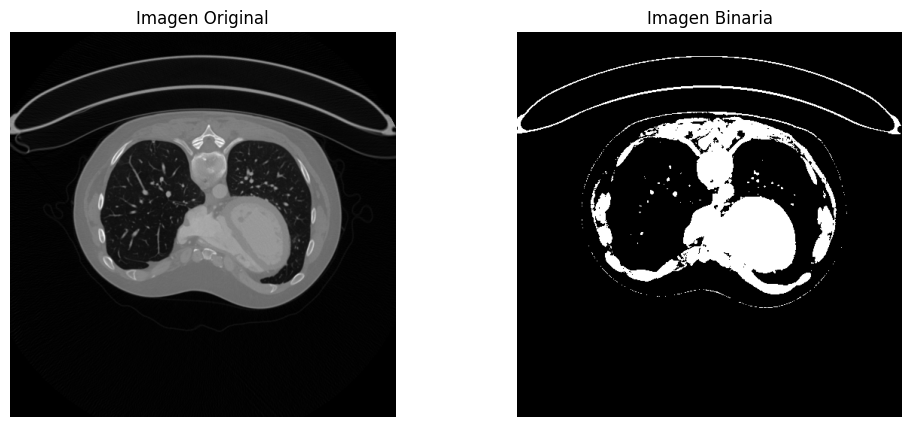

In [ ]:
umbral = 120

_, imagen_binaria = cv2.threshold(
    imagen_normalizada,
    umbral,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada,cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_binaria,cmap="gray")
plt.title("Imagen Binaria")
plt.axis("off")

plt.show()

La umbralización permite separar las regiones con intensidades superiores al valor seleccionado, generando una imagen binaria que servirá como máscara para las operaciones lógicas posteriores.

**8. Operaciones lógicas**

Las operaciones lógicas permiten combinar una imagen con una máscara binaria para resaltar únicamente las regiones de interés.

Operación AND

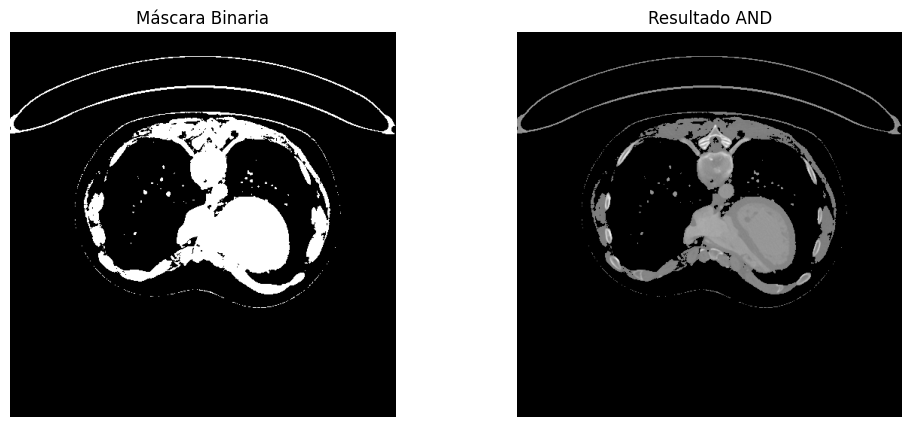

In [ ]:
imagen_and = cv2.bitwise_and(
    imagen_normalizada,
    imagen_normalizada,
    mask=imagen_binaria
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_binaria,cmap="gray")
plt.title("Máscara Binaria")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_and,cmap="gray")
plt.title("Resultado AND")
plt.axis("off")

plt.show()

Operación OR

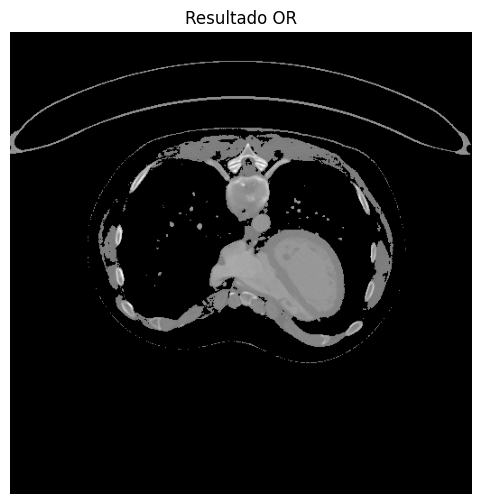

In [ ]:
imagen_or = cv2.bitwise_or(
    imagen_normalizada,
    imagen_normalizada,
    mask=imagen_binaria
)

plt.figure(figsize=(6,6))
plt.imshow(imagen_or,cmap="gray")
plt.title("Resultado OR")
plt.axis("off")
plt.show()

**9. Segmentación interactiva**

Con el fin de analizar el efecto del valor de umbral sobre la segmentación, se implementó un control deslizante que permite modificar dicho valor y visualizar el resultado en tiempo real.

In [ ]:
from ipywidgets import interact, IntSlider

@interact(
    umbral=IntSlider(
        min=0,
        max=255,
        step=1,
        value=120,
        description="Umbral"
    )
)
def segmentacion_interactiva(umbral):

    _, imagen_segmentada = cv2.threshold(
        imagen_normalizada,
        umbral,
        255,
        cv2.THRESH_BINARY
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(imagen_normalizada, cmap="gray")
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(imagen_segmentada, cmap="gray")
    plt.title(f"Segmentación (Umbral = {umbral})")
    plt.axis("off")

    plt.show()

interactive(children=(IntSlider(value=120, description='Umbral', max=255), Output()), _dom_classes=('widget-in…

**10. Detección de bordes mediante Sobel**

El operador Sobel permite detectar cambios bruscos de intensidad en la imagen mediante el cálculo del gradiente, resaltando los bordes de las estructuras anatómicas.

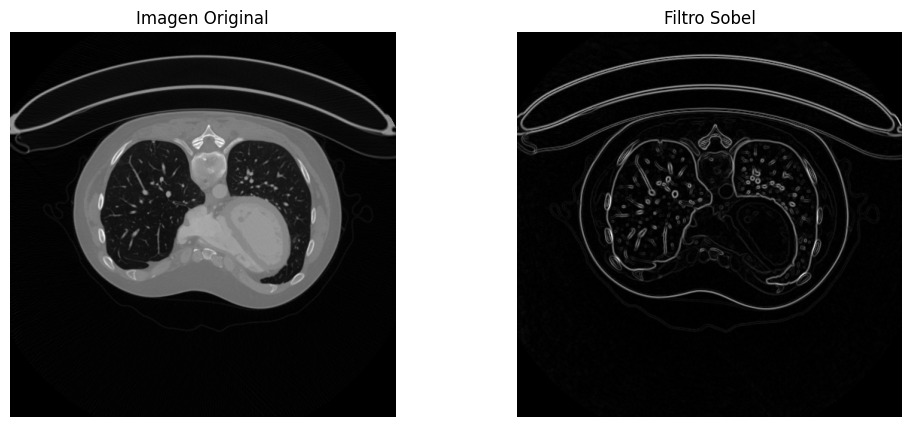

In [ ]:
sobel_x = cv2.Sobel(
    imagen_normalizada,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

sobel_y = cv2.Sobel(
    imagen_normalizada,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

imagen_sobel = cv2.magnitude(sobel_x, sobel_y)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada,cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_sobel,cmap="gray")
plt.title("Filtro Sobel")
plt.axis("off")

plt.show()

El operador Sobel resalta los bordes presentes en la imagen al detectar cambios de intensidad tanto en dirección horizontal como vertical.

**11. Detección de bordes mediante Laplaciano**

El operador Laplaciano corresponde a un filtro de segundo orden que enfatiza cambios abruptos de intensidad, permitiendo identificar contornos en la imagen.

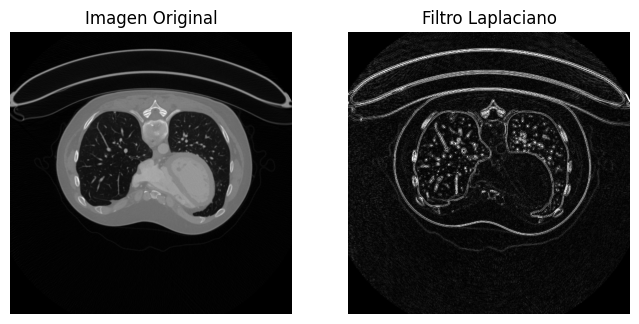

In [ ]:
imagen_laplaciana = cv2.Laplacian(
    imagen_normalizada,
    cv2.CV_64F,
    ksize=3
)

imagen_laplaciana = cv2.convertScaleAbs(imagen_laplaciana)

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada,cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_laplaciana,cmap="gray")
plt.title("Filtro Laplaciano")
plt.axis("off")

plt.show()

El filtro Laplaciano resalta los contornos de las estructuras presentes en la imagen al calcular la segunda derivada de la intensidad.

**12. Transformada de Fourier**

La Transformada de Fourier permite representar la imagen en el dominio de la frecuencia. Esto facilita el análisis de las componentes de baja y alta frecuencia, así como la aplicación de filtros frecuenciales para mejorar la calidad de la imagen.

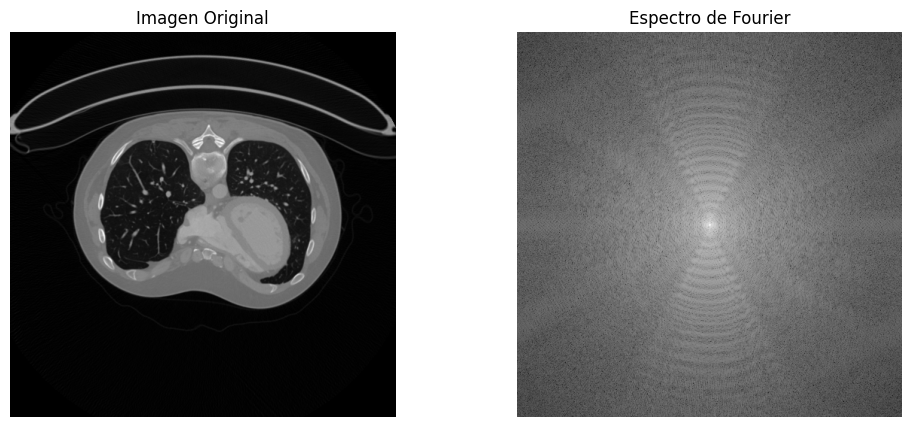

In [ ]:
# FFT
f = np.fft.fft2(imagen_normalizada)

# Centrar espectro
fshift = np.fft.fftshift(f)

# Magnitud
magnitud = np.log(np.abs(fshift) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(imagen_normalizada, cmap="gray")
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(magnitud, cmap="gray")
plt.title("Espectro de Fourier")
plt.axis("off")

plt.show()

El espectro obtenido permite observar la distribución de las frecuencias presentes en la imagen. Las bajas frecuencias se concentran en el centro del espectro, mientras que las altas frecuencias se encuentran hacia los extremos.

**13. Filtrado en el dominio de la frecuencia**

Se aplicó un filtro pasa bajas para eliminar componentes de alta frecuencia y posteriormente reconstruir la imagen mediante la transformada inversa.

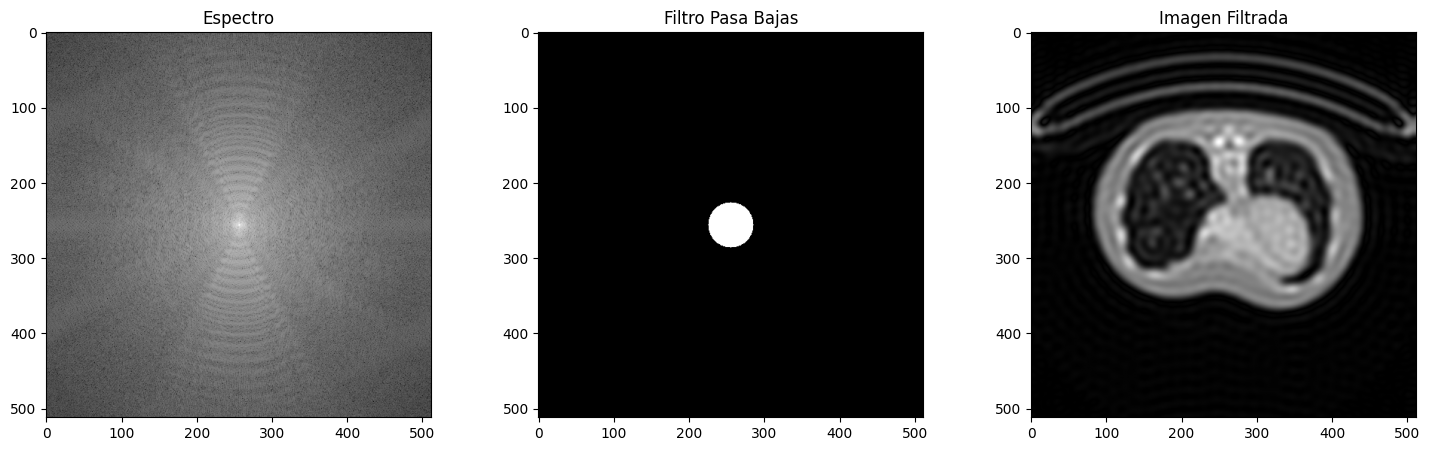

In [ ]:
rows, cols = imagen_normalizada.shape
crow, ccol = rows // 2, cols // 2

# Crear máscara
mask = np.zeros((rows, cols), np.uint8)

radio = 30

Y, X = np.ogrid[:rows, :cols]

dist = np.sqrt((X - ccol)**2 + (Y - crow)**2)

mask[dist <= radio] = 1

# Aplicar máscara
fshift_filtrado = fshift * mask

# Transformada inversa
f_ishift = np.fft.ifftshift(fshift_filtrado)

img_back = np.fft.ifft2(f_ishift)

imagen_fourier = np.abs(img_back)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(magnitud, cmap="gray")
plt.title("Espectro")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Filtro Pasa Bajas")

plt.subplot(1,3,3)
plt.imshow(imagen_fourier, cmap="gray")
plt.title("Imagen Filtrada")

plt.show()

Al aplicar el filtro pasa bajas se eliminan las componentes de alta frecuencia, obteniendo una imagen con menor nivel de detalle y menor presencia de ruido.